In [5]:
# -*- coding: utf-8 -*-
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams.update({
    "font.size": 20,
    "legend.fontsize": 18,
})

G = 1  # kpc (km/s)^2 / Msun

# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
def load_data(filename, out_dir="../out"):
    """Load a single simulation output file."""
    names = ["x", "y", "z", "fx", "fy", "fz", "phi"]
    file_path = os.path.join(out_dir, filename)
    
    df = pd.read_csv(file_path, header=None, sep=r"\s+", names=names)
    
    # Shift coordinates to start at 0
    df["x"] -= df["x"].min()
    df["y"] -= df["y"].min()
    df["z"] -= df["z"].min()
    
    return df

# ---------------------------------------------------------------------
# Compute analytical solution for single point mass
# ---------------------------------------------------------------------
def compute_analytical_single(x_grid, y_grid, z_grid, box_length=1.0):
    """
    Compute analytical potential for a single point mass at box center.
    Phi = -M/r where M=1.
    """
    xc = box_length / 2.0
    yc = box_length / 2.0
    zc = box_length / 2.0
    
    r = np.sqrt((x_grid - xc)**2 + (y_grid - yc)**2 + (z_grid - zc)**2)
    
    # Avoid division by zero at center
    r = np.maximum(r, 1e-10)
    
    phi_analytical = -1.0 / r
    
    return phi_analytical

# ---------------------------------------------------------------------
# Compute analytical solution for two uniform spheres
# ---------------------------------------------------------------------
def compute_analytical_spheres(x_grid, y_grid, z_grid, levelmin, box_length=1.0):
    """
    Compute analytical potential for two uniform-density spheres.
    
    For levelmin=8:
        R1=0.1, R2=0.2, x1=0.2, x2=0.7, y1=y2=0.5, z1=z2=0.5
    For levelmin=9:
        R1=0.1, R2=0.2, x1=0.7, x2=1.2, y1=y2=1.0, z1=z2=1.0
    """
    rho = 1.0
    R1, R2 = 0.1, 0.2
    
    if levelmin == 8:
        x1, x2 = 0.2, 0.7
        y1 = y2 = 0.5
        z1 = z2 = 0.5
    elif levelmin == 9:
        x1, x2 = 0.7, 1.2
        y1 = y2 = 1.0
        z1 = z2 = 1.0
    else:
        raise ValueError(f"Unsupported levelmin={levelmin} for spheres")
    
    # Masses
    M1 = (4/3) * np.pi * R1**3 * rho
    M2 = (4/3) * np.pi * R2**3 * rho
    
    # Distances from each sphere center
    r1 = np.sqrt((x_grid - x1)**2 + (y_grid - y1)**2 + (z_grid - z1)**2)
    r2 = np.sqrt((x_grid - x2)**2 + (y_grid - y2)**2 + (z_grid - z2)**2)
    
    def phi_sphere(r, R, M):
        """Analytical uniform-density sphere potential."""
        phi_out = -G * M / r
        phi_in = -1.5 * G * M / R + 0.5 * G * M * r**2 / (R**3)
        return np.where(r >= R, phi_out, phi_in)
    
    phi_analytical = phi_sphere(r1, R1, M1) + phi_sphere(r2, R2, M2)
    
    return phi_analytical

# ---------------------------------------------------------------------
# Main plotting function
# ---------------------------------------------------------------------
def plot_3x2_comparison(filenames, labels, z_slice, levelmin=7, 
                        box_length=1.0, problem_type="single", out_dir="../out"):
    """
    Create a 3x2 plot:
    - Top row: 3 simulation potentials
    - Bottom row: relative error vs analytical solution
    
    Parameters:
    -----------
    filenames : list of 3 strings
        Simulation output filenames
    labels : list of 3 strings
        Labels for each simulation
    z_slice : float
        Z-coordinate for the slice
    levelmin : int
        Grid resolution level
    box_length : float
        Physical box size
    problem_type : str
        "single" for point mass, "spheres" for two spheres
    """
    
    # Load all three simulations
    dfs = [load_data(fn, out_dir) for fn in filenames]
    
    # Extract z-slice for each
    df_slices = [df[np.isclose(df["z"], z_slice)] for df in dfs]
    
    # Create 2D grids for each simulation
    grids = [df_slice.pivot(index="y", columns="x", values="phi") for df_slice in df_slices]
    
    # Get grid dimensions
    nx, ny = grids[0].shape
    dx = box_length / (2 ** (levelmin-1))
    print(nx, (2 ** (levelmin-1)))
    
    # Create coordinate grids at cell centers
    x_1d = (np.arange(nx) + 0.5) * dx
    y_1d = (np.arange(ny) + 0.5) * dx
    z_val = (z_slice + 0.5) * dx
    
    x_grid, y_grid = np.meshgrid(x_1d, y_1d)
    z_grid = np.full_like(x_grid, z_val)
    
    # Compute analytical solution
    if problem_type == "single":
        phi_analytical = compute_analytical_single(x_grid, y_grid, z_grid, box_length)
    elif problem_type == "spheres":
        phi_analytical = compute_analytical_spheres(x_grid, y_grid, z_grid, levelmin, box_length)
    else:
        raise ValueError("problem_type must be 'single' or 'spheres'")
    
    # Compute relative errors
    with np.errstate(divide="ignore", invalid="ignore"):
        rel_errors = [(grid.values - phi_analytical) / phi_analytical for grid in grids]
    
    # Create figure
    fig, axes = plt.subplots(
        2, 3,
        figsize=(15, 10),
        constrained_layout=True
    )
    
    # Determine common color scale for potentials
    vmin_phi = min(grid.values.min() for grid in grids)
    vmax_phi = max(grid.values.max() for grid in grids)
    
    # Determine common color scale for errors
    vmin_err = min(err.min() for err in rel_errors)
    vmax_err = max(err.max() for err in rel_errors)
    # Make symmetric around zero
    vmax_err_sym = max(abs(vmin_err), abs(vmax_err))
    vmin_err_sym = -vmax_err_sym
    
    # Top row: simulation potentials
    ims_phi = []
    for i in range(3):
        ax = axes[0, i]
        im = ax.imshow(
            grids[i].values,
            origin="lower",
            cmap="viridis",
            vmin=vmin_phi,
            vmax=vmax_phi,
            extent=[0, box_length, 0, box_length],
        )

        ims_phi.append(im)
        ax.set_title(f"{labels[i]}", fontsize=20)
        ax.set_xlabel("x")
        if i == 0:
            ax.set_ylabel("y")

    # One shared colorbar for top row (rightmost)
    cbar_phi = fig.colorbar(
        ims_phi[-1],
        ax=axes[0, :],
        location="right",
        fraction=0.046,
        pad=0.04,
    )
    cbar_phi.set_label(r"$\Phi$")


    # Bottom row: relative errors
    ims_err = []
    for i in range(3):
        ax = axes[1, i]
        im = ax.imshow(
            rel_errors[i],
            origin="lower",
            cmap="RdYlGn",
            vmin=vmin_err_sym,
            vmax=vmax_err_sym,
            extent=[0, box_length, 0, box_length],
        )

        ims_err.append(im)

        err_mean = np.nanmean(np.abs(rel_errors[i]))
        err_max = np.nanmax(np.abs(rel_errors[i]))

        ax.set_title(
            f"Relative Error\nMean: {err_mean:.2e}, Max: {err_max:.2e}",
            fontsize=15,
        )
        ax.set_xlabel("x")
        if i == 0:
            ax.set_ylabel("y")

    # One shared colorbar for bottom row (rightmost)
    cbar_err = fig.colorbar(
        ims_err[-1],
        ax=axes[1, :],
        location="right",
        fraction=0.046,
        pad=0.04,
    )
    cbar_err.set_label(
        r"$(\Phi_\mathrm{sim} - \Phi_\mathrm{true})/\Phi_\mathrm{true}$"
    )

    
    # Overall title
    problem_str = "Single Point Mass" if problem_type == "single" else "Two Uniform Spheres"
        
    # Save figure
    os.makedirs("./fig", exist_ok=True)
    safe_labels = "_".join([label.replace(" ", "_") for label in labels])
    filename = f"./fig/comparison_3x2_{problem_type}_lv{levelmin}_{safe_labels}.pdf"
    plt.savefig(filename, dpi=250, bbox_inches="tight")
    print(f"Saved: {filename}")
    plt.show()


Plotting: Two Spheres (levelmin=9)
256 256
Saved: ./fig/comparison_3x2_spheres_lv9_FMM-1_FMM-2_MG.pdf


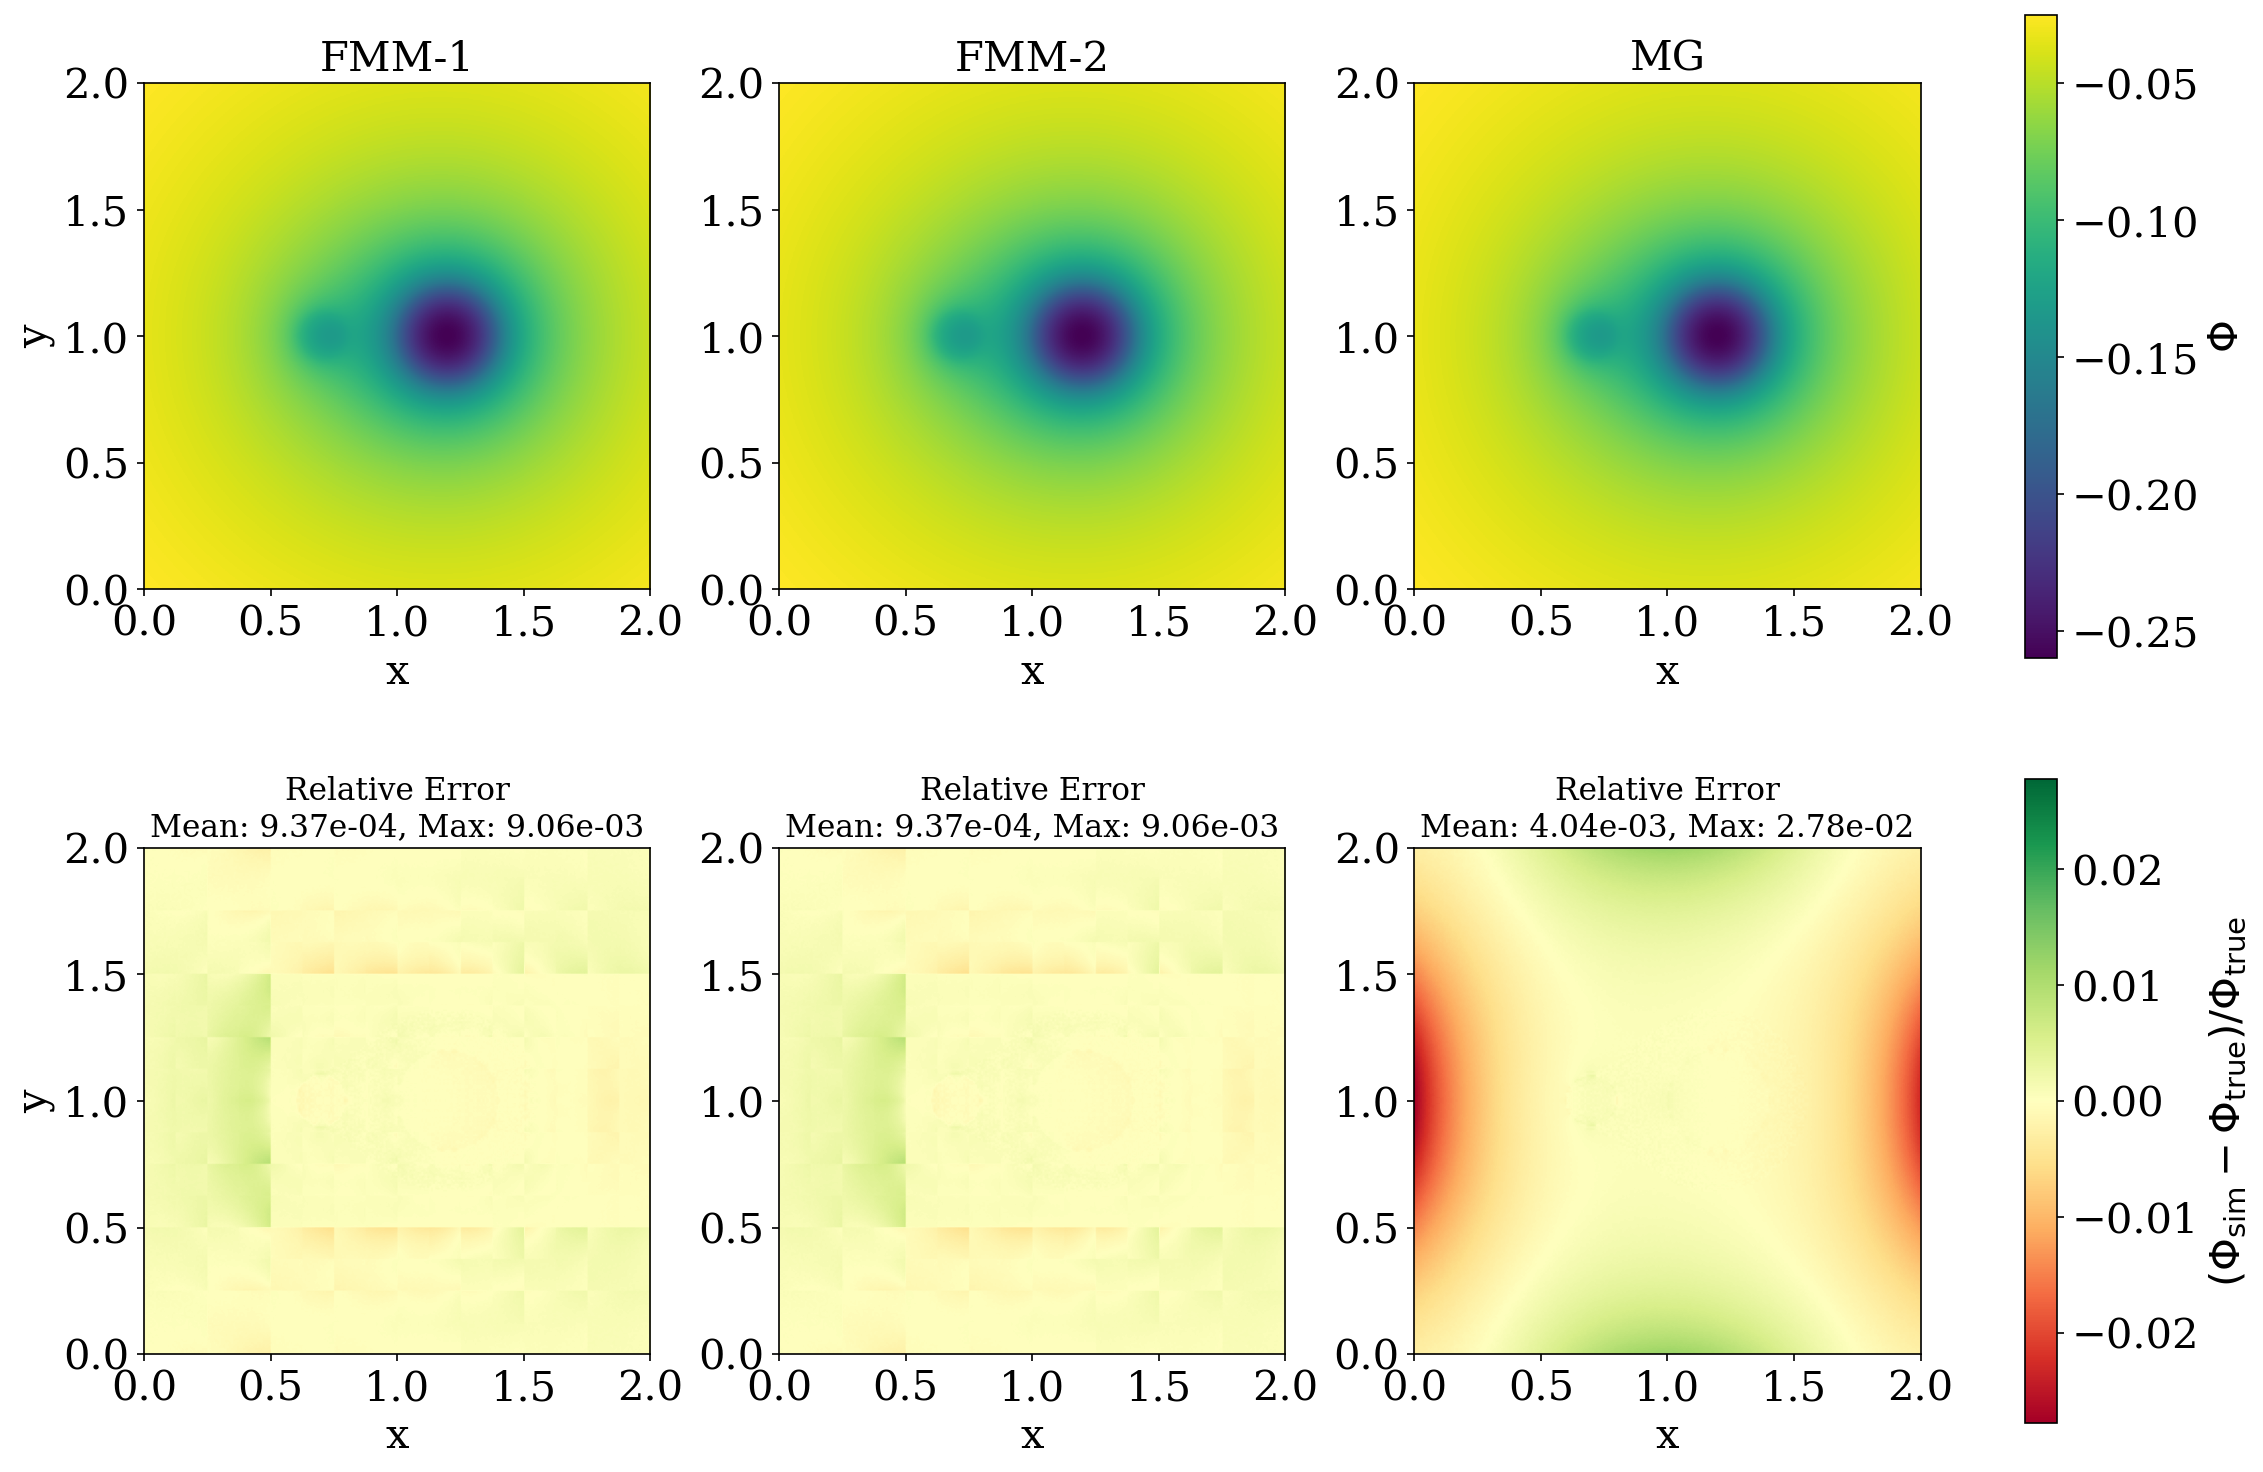


All plots completed!


In [6]:
print("\n" + "=" * 60)
print("Plotting: Two Spheres (levelmin=9)")
print("=" * 60)

filenames_spheres_9 = [
    "spheres_lv9_fmm_1.out",
    "spheres_lv9_fmm_2.out",
    "spheres_lv9_mg.out"
]

labels_spheres_9 = [
    "FMM-1",
    "FMM-2",
    "MG"
]

plot_3x2_comparison(
    filenames=filenames_spheres_9,
    labels=labels_spheres_9,
    z_slice=128,
    levelmin=9,
    box_length=2.0,
    problem_type="spheres",
    out_dir="../out/paper_results/"
)

print("\n" + "=" * 60)
print("All plots completed!")
print("=" * 60)


Plotting: Two Spheres (levelmin=9)
256 256
Saved: ./fig/comparison_3x2_single_lv9_FMM-1_FMM-2_MG.pdf


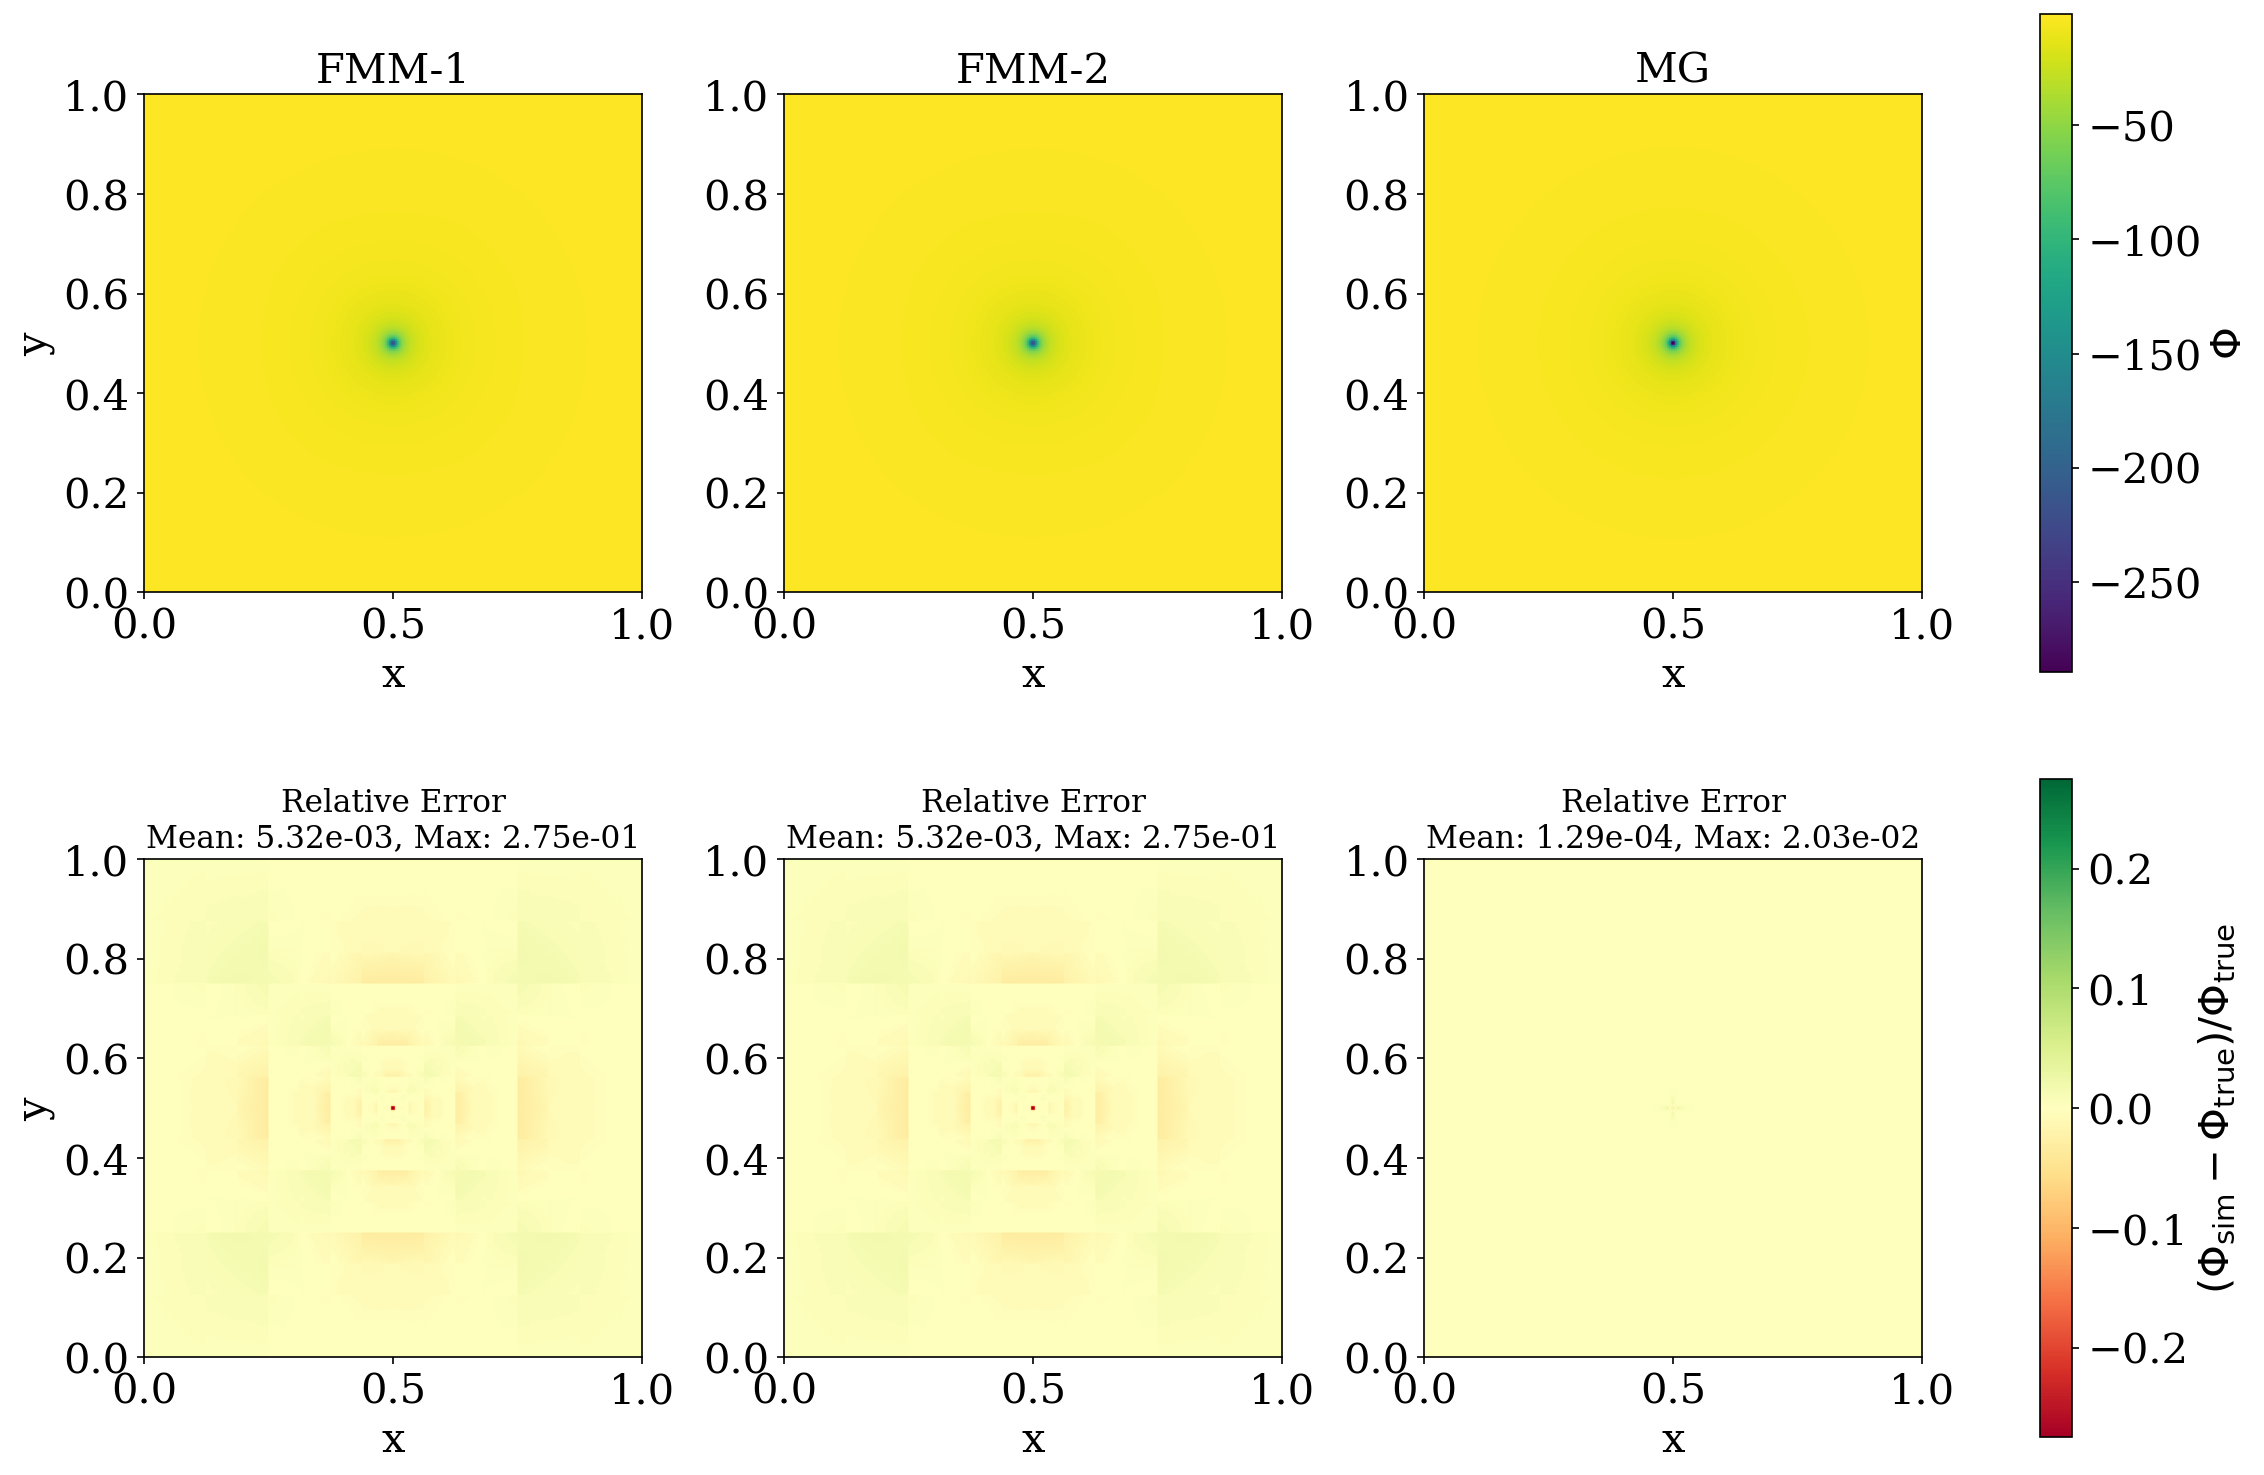


All plots completed!


In [3]:
print("\n" + "=" * 60)
print("Plotting: Two Spheres (levelmin=9)")
print("=" * 60)

filenames_spheres_9 = [
    "single_lv9_fmm_1.out",
    "single_lv9_fmm_2.out",
    "single_lv9_mg.out"
]

labels_spheres_9 = [
    "FMM-1",
    "FMM-2",
    "MG"
]

plot_3x2_comparison(
    filenames=filenames_spheres_9,
    labels=labels_spheres_9,
    z_slice=128,
    levelmin=9,
    box_length=1.0,
    problem_type="single",
    out_dir="../out"
)

print("\n" + "=" * 60)
print("All plots completed!")
print("=" * 60)

In [15]:
# ---------------------------------------------------------------------
# Profile plot for SPHERES: full -x to +x sweep
# ---------------------------------------------------------------------
def plot_spheres_profile(filenames, labels, z_slice, levelmin=8, 
                         box_length=1.0, out_dir="../out"):
    """
    For spheres: plot full horizontal profile from left to right edge.
    Shows how potential varies across both spheres.
    """
    
    # Load all three simulations
    dfs = [load_data(fn, out_dir) for fn in filenames]
    
    # Extract z-slice for each
    df_slices = [df[np.isclose(df["z"], z_slice)] for df in dfs]
    
    # Create 2D grids for each simulation
    grids = [df_slice.pivot(index="y", columns="x", values="phi") for df_slice in df_slices]
    
    # Get grid dimensions
    nx, ny = grids[0].shape
    dx = box_length / (2 ** (levelmin-1))
    
    # Create coordinate grids at cell centers
    x_1d = (np.arange(nx) + 0.5) * dx
    y_1d = (np.arange(ny) + 0.5) * dx
    z_val = (z_slice + 0.5) * dx
    
    # Take horizontal slice through middle
    yc_idx = ny // 2
    x_coords = x_1d
    phi_sims = [grid.values[yc_idx, :] for grid in grids]
    
    # Compute analytical solution along this line
    x_grid_1d = x_coords
    y_grid_1d = np.full_like(x_coords, y_1d[yc_idx])
    z_grid_1d = np.full_like(x_coords, z_val)
    
    x_grid, y_grid = np.meshgrid(x_1d, y_1d)
    z_grid = np.full_like(x_grid, z_val)
    phi_analytical_2d = compute_analytical_spheres(x_grid, y_grid, z_grid, levelmin, box_length)
    phi_analytical_1d = phi_analytical_2d[yc_idx, :]
    
    # Get sphere parameters for markers
    rho = 1.0
    R1, R2 = 0.1, 0.2
    if levelmin == 8:
        x1, x2 = 0.2, 0.7
    elif levelmin == 9:
        x1, x2 = 0.7, 1.2
    
    # Compute relative errors
    with np.errstate(divide="ignore", invalid="ignore"):
        rel_errors = [(phi_sim - phi_analytical_1d) / phi_analytical_1d 
                      for phi_sim in phi_sims]
    
    # Create figure with 3 panels
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
    
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    
    # ===== Panel 1: Potential profiles =====
    ax1.plot(x_coords, phi_analytical_1d, 'k-', linewidth=1, label='Analytical', zorder=10, alpha=.5)
    ax1.axvline(x1, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
    ax1.axvline(x2, color='orange', linestyle='--', alpha=0.5, linewidth=1.5)
    
    for i, (phi_sim, label, color) in enumerate(zip(phi_sims, labels, colors)):
        ax1.plot(x_coords, phi_sim, alpha=0.6, label=label, color=color)
    
    # Mark sphere boundaries
    ax1.axvspan(x1-R1, x1+R1, color='red', alpha=0.1, zorder=0)
    ax1.axvspan(x2-R2, x2+R2, color='orange', alpha=0.1, zorder=0)
    
    ax1.set_ylabel(r"$\Phi$")
    ax1.legend(loc='lower left', framealpha=0.9)
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # ===== Panel 2: Relative error (linear scale) =====
    for i, (rel_err, label, color) in enumerate(zip(rel_errors, labels, colors)):
        ax2.plot(x_coords, rel_err * 100, '-', linewidth=1.5, alpha=0.8, label=label, color=color)
    
    ax2.axhline(0, color='k', linestyle='-', linewidth=0.8, alpha=0.7)
    ax2.axvline(x1, color='red', linestyle='--', alpha=0.3, linewidth=1)
    ax2.axvline(x2, color='orange', linestyle='--', alpha=0.3, linewidth=1)
    ax2.axvspan(x1-R1, x1+R1, color='red', alpha=0.1, zorder=0)
    ax2.axvspan(x2-R2, x2+R2, color='orange', alpha=0.1, zorder=0)
    
    ax2.set_ylabel("Relative Error [%]")
    #ax2.legend(loc='best', framealpha=0.9)
    ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax2.set_ylim(-3,3)
    
    # ===== Panel 3: Log absolute error =====
    for i, (rel_err, label, color) in enumerate(zip(rel_errors, labels, colors)):
        ax3.semilogy(x_coords, np.abs(rel_err) + 1e-12, '-', linewidth=1.5, 
                     alpha=0.8, label=label, color=color)
    
    ax3.axvline(x1, color='red', linestyle='--', alpha=0.3, linewidth=1)
    ax3.axvline(x2, color='orange', linestyle='--', alpha=0.3, linewidth=1)
    ax3.axvspan(x1-R1, x1+R1, color='red', alpha=0.1, zorder=0)
    ax3.axvspan(x2-R2, x2+R2, color='orange', alpha=0.1, zorder=0)
    
    ax3.set_xlabel("x")
    ax3.set_ylabel(r"$|\mathrm{Relative\ Error}|$")
    ax3.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    for ax in (ax1, ax2, ax3):
        if ax == ax2:
            ax.set_ylabel(ax.get_ylabel(), labelpad=15)
        else:
            ax.set_ylabel(ax.get_ylabel(), labelpad=8)
    
    plt.tight_layout()

    # Save figure
    os.makedirs("./fig", exist_ok=True)
    safe_labels = "_".join([label.replace(" ", "_") for label in labels])
    filename = f"./fig/profile_spheres_lv{levelmin}_{safe_labels}.pdf"
    plt.savefig(filename, dpi=250, bbox_inches="tight")
    print(f"Saved: {filename}")
    plt.show()


Plotting: Two Spheres (levelmin=9)
Saved: ./fig/profile_spheres_lv9_FMM-1_MG.pdf


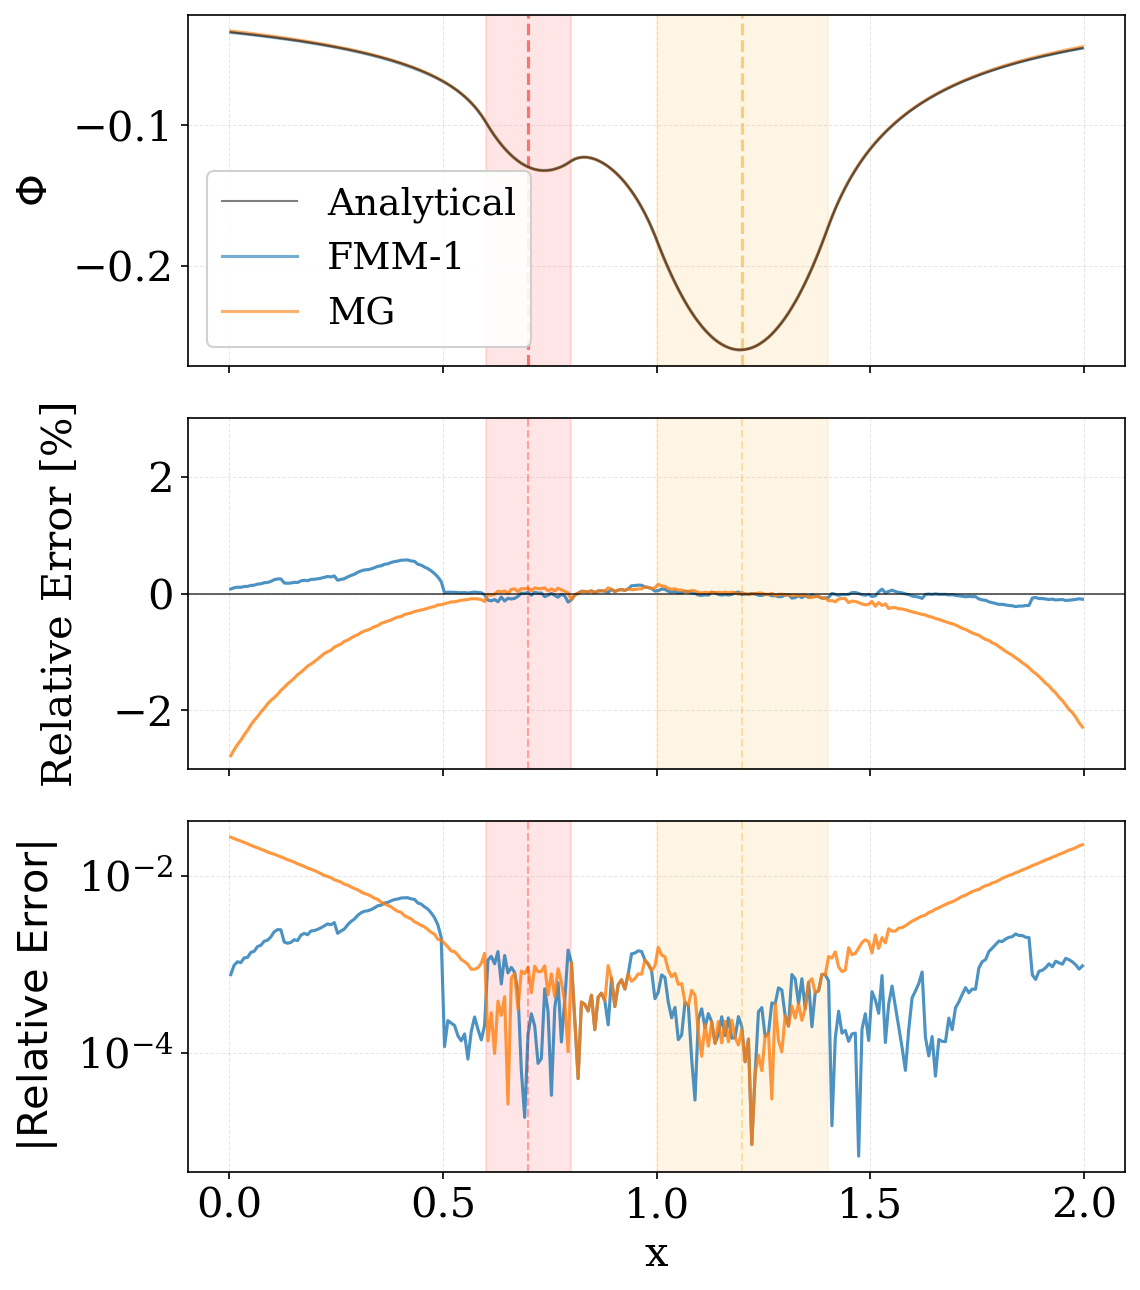


All plots completed!


In [16]:
print("\n" + "=" * 60)
print("Plotting: Two Spheres (levelmin=9)")
print("=" * 60)

filenames_spheres_9 = [
    "spheres_lv9_fmm_1.out",
    #"spheres_lv9_fmm_2.out",
    "spheres_lv9_mg.out"
]

labels_spheres_9 = [
    "FMM-1",
    #"FMM-2",
    "MG"
]

plot_spheres_profile(
    filenames=filenames_spheres_9,
    labels=labels_spheres_9,
    z_slice=128,
    levelmin=9,
    box_length=2.0,
    out_dir="../out"
)

print("\n" + "=" * 60)
print("All plots completed!")
print("=" * 60)

In [6]:

# ---------------------------------------------------------------------
# Profile plot for SINGLE: radial profiles from center
# ---------------------------------------------------------------------
def plot_single_profile(filenames, labels, z_slice, levelmin=7, 
                        box_length=1.0, out_dir="../out"):
    """
    For single point mass: plot radial profiles along multiple directions.
    Shows spherical symmetry (or lack thereof) of the solution.
    """
    
    # Load all three simulations
    dfs = [load_data(fn, out_dir) for fn in filenames]
    
    # Extract z-slice for each
    df_slices = [df[np.isclose(df["z"], z_slice)] for df in dfs]
    
    # Create 2D grids for each simulation
    grids = [df_slice.pivot(index="y", columns="x", values="phi") for df_slice in df_slices]
    
    # Get grid dimensions
    nx, ny = grids[0].shape
    dx = box_length / (2 ** (levelmin-1))
    
    # Create coordinate grids
    x_1d = (np.arange(nx) + 0.5) * dx
    y_1d = (np.arange(ny) + 0.5) * dx
    z_val = (z_slice + 0.5) * dx
    
    xc_phys = box_length / 2.0
    yc_phys = box_length / 2.0
    zc_phys = z_val
    
    xc_idx = nx // 2
    yc_idx = ny // 2
    
    # Define multiple line-of-sight directions
    directions = {
        '+x': {'x': x_1d[xc_idx:], 'y': np.full(nx - xc_idx, yc_phys), 'label': '+x axis'},
        '-x': {'x': x_1d[:xc_idx+1][::-1], 'y': np.full(xc_idx + 1, yc_phys), 'label': '-x axis'},
        '+y': {'x': np.full(ny - yc_idx, xc_phys), 'y': y_1d[yc_idx:], 'label': '+y axis'},
        '-y': {'x': np.full(yc_idx + 1, xc_phys), 'y': y_1d[:yc_idx+1][::-1], 'label': '-y axis'},
        'diag+': {'x': x_1d[xc_idx:], 'y': y_1d[yc_idx:], 'label': '+diagonal'},
        'diag-': {'x': x_1d[xc_idx:], 'y': y_1d[yc_idx:][::-1], 'label': '×diagonal'}
    }
    
    # For each direction, extract simulation values and compute analytical
    profiles = {}
    
    for dir_name, dir_info in directions.items():
        x_coords = dir_info['x']
        y_coords = dir_info['y']
        n_pts = min(len(x_coords), len(y_coords))
        x_coords = x_coords[:n_pts]
        y_coords = y_coords[:n_pts]
        
        # Compute distance from center
        r = np.sqrt((x_coords - xc_phys)**2 + (y_coords - yc_phys)**2)
        
        # Analytical solution
        phi_analytical = -1.0 / np.maximum(r, 1e-10)
        
        # Extract simulation values (need to find nearest grid points)
        phi_sims = []
        for grid in grids:
            x_idx = np.clip(np.round((x_coords / dx) - 0.5).astype(int), 0, nx-1)
            y_idx = np.clip(np.round((y_coords / dx) - 0.5).astype(int), 0, ny-1)
            phi_sim = grid.values[y_idx, x_idx]
            phi_sims.append(phi_sim)
        
        profiles[dir_name] = {
            'r': r,
            'phi_analytical': phi_analytical,
            'phi_sims': phi_sims,
            'label': dir_info['label']
        }
    
    # Create figure with 3 panels
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), 
                                        gridspec_kw={'height_ratios': [2, 1, 1]},
                                        sharex=True)
    
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    markers = ['o', 's', '^', 'v', 'd', 'x']
    linestyles = ['-', '--', '-.', ':', '-', '--']
    
    # ===== Panel 1: Potential profiles (log-log) =====
    # Plot analytical first
    r_analytical = np.logspace(-3, np.log10(box_length/np.sqrt(2)), 200)
    phi_analytical = -1.0 / r_analytical
    ax1.loglog(r_analytical, np.abs(phi_analytical), 'k-', linewidth=1, 
               label='Analytical', zorder=10, alpha=0.8)
    
    # Plot each direction for each simulation
    for i, (label, color) in enumerate(zip(labels, colors)):
        for j, (dir_name, profile) in enumerate(profiles.items()):
            r = profile['r']
            phi_sim = profile['phi_sims'][i]
            if j == 0:  # Only add label once per simulation
                ax1.loglog(r, np.abs(phi_sim), markers[j], ms=1, alpha=0.5, 
                          color=color, label=label, linestyle='none')
            else:
                ax1.loglog(r, np.abs(phi_sim), markers[j], ms=1, alpha=0.5, 
                          color=color, linestyle='none')
    
    ax1.set_ylabel(r"$|\Phi|$")
    ax1.legend(loc='lower left', framealpha=0.9)
    ax1.grid(True, which='both', alpha=0.3, linestyle='--', linewidth=0.5)
    
    # ===== Panel 2: Relative error for +x direction only (cleaner) =====
    profile_x = profiles['+x']
    r_x = profile_x['r']
    phi_analytical_x = profile_x['phi_analytical']
    
    for i, (label, color) in enumerate(zip(labels, colors)):
        phi_sim_x = profile_x['phi_sims'][i]
        rel_err = (phi_sim_x - phi_analytical_x) / phi_analytical_x
        ax2.semilogx(r_x, rel_err * 100, '-', linewidth=2, alpha=0.8, label=label, color=color)
    
    ax2.axhline(0, color='k', linestyle='-', linewidth=0.8, alpha=0.7)
    ax2.set_ylabel("Relative Error [%]\n(+x direction)")
    ax2.legend(loc='best', framealpha=0.9)
    ax2.grid(True, which='both', alpha=0.3, linestyle='--', linewidth=0.5)
    ax2.set_ylim(-5, 5)
    
    # ===== Panel 3: Log absolute error - all directions =====
    for i, (label, color) in enumerate(zip(labels, colors)):
        for j, (dir_name, profile) in enumerate(profiles.items()):
            r = profile['r']
            phi_sim = profile['phi_sims'][i]
            phi_analytical = profile['phi_analytical']
            rel_err = (phi_sim - phi_analytical) / phi_analytical
            
            if j == 0:  # Only add label once per simulation
                ax3.loglog(r, np.abs(rel_err) + 1e-12, linestyles[j], 
                          linewidth=1.2, alpha=0.6, color=color, label=label)
            else:
                ax3.loglog(r, np.abs(rel_err) + 1e-12, linestyles[j], 
                          linewidth=1.2, alpha=0.6, color=color)
    
    ax3.set_xlabel("r")
    ax3.set_ylabel(r"$|\mathrm{Relative\ Error}|$")
    ax3.legend(loc='best', framealpha=0.9)
    ax3.grid(True, which='both', alpha=0.3, linestyle='--', linewidth=0.5)
    
    plt.tight_layout()
    
    # Save figure
    os.makedirs("./fig", exist_ok=True)
    safe_labels = "_".join([label.replace(" ", "_") for label in labels])
    filename = f"./fig/profile_single_lv{levelmin}_{safe_labels}.pdf"
    plt.savefig(filename, dpi=250, bbox_inches="tight")
    print(f"Saved: {filename}")
    plt.show()


Plotting: Single Point Mass
Saved: ./fig/profile_single_lv9_FMM-1_FMM-2_MG.pdf


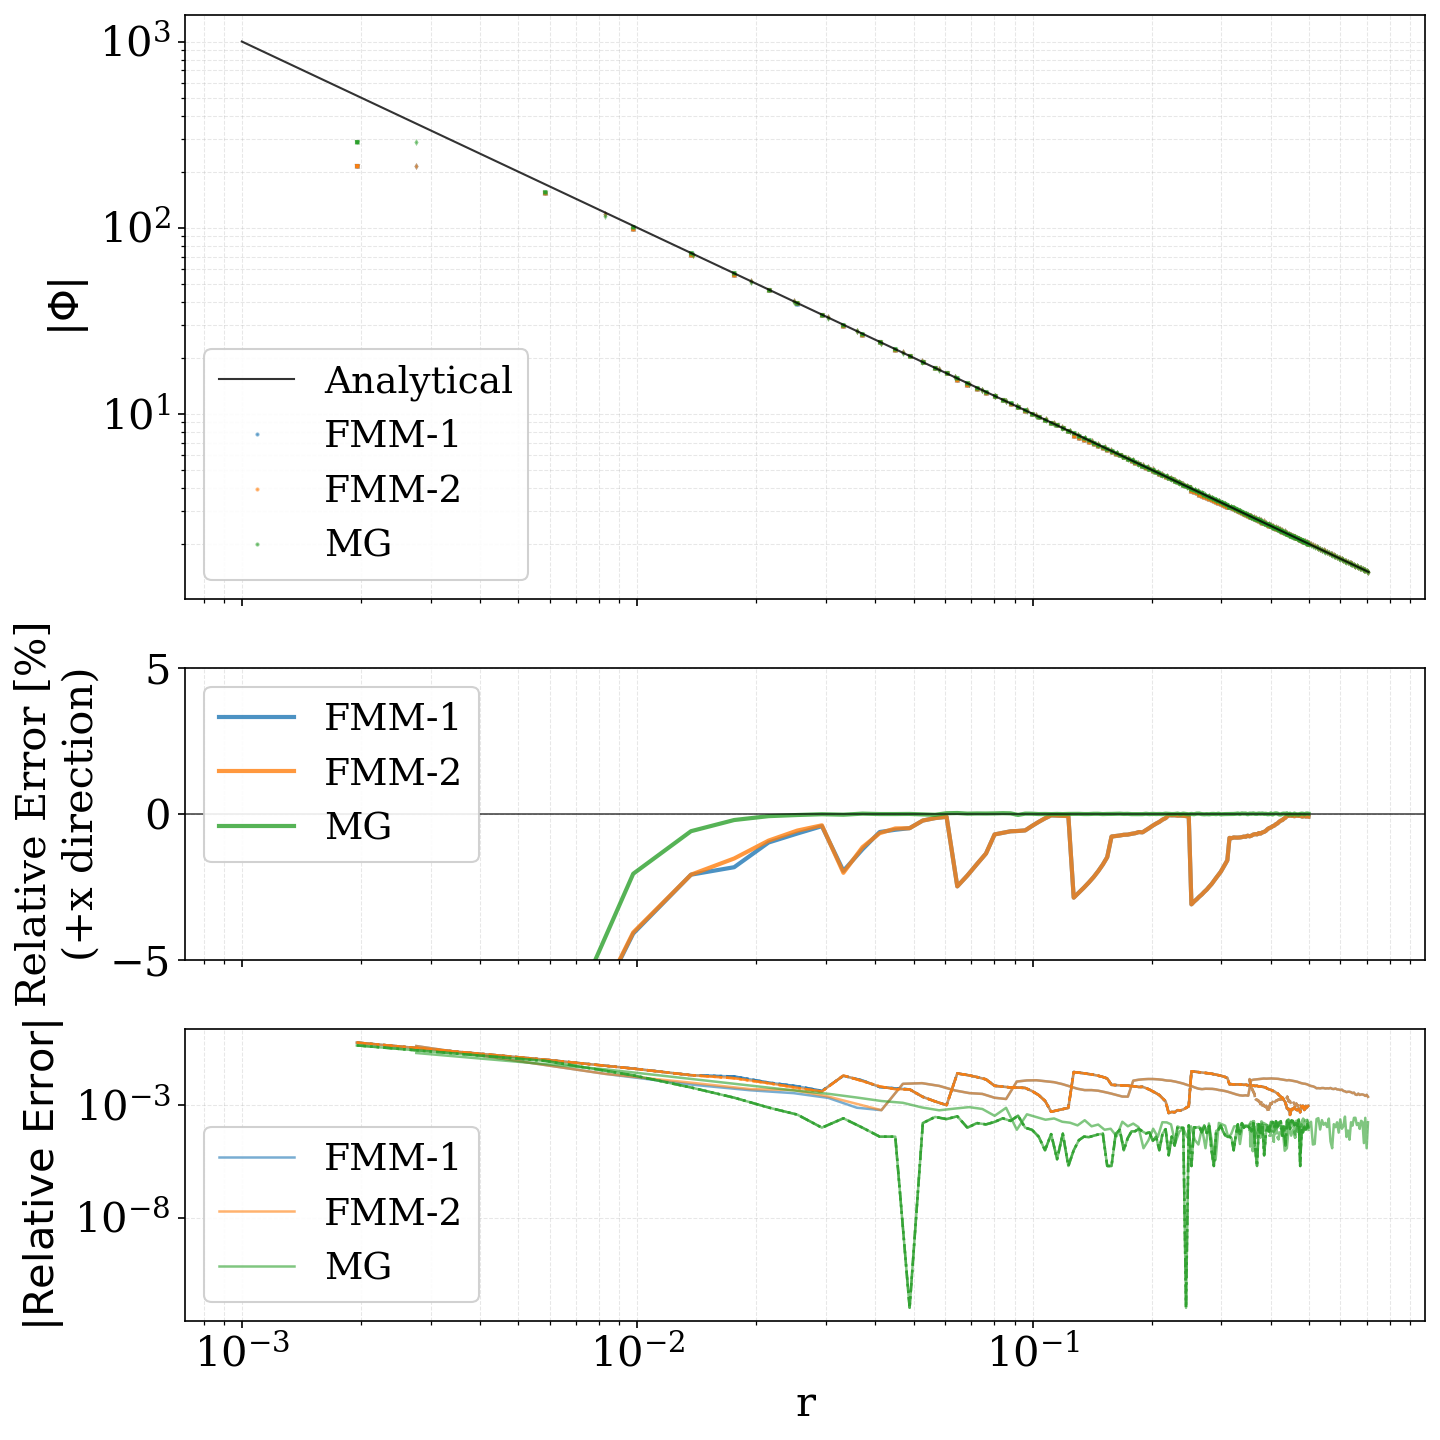


All plots completed!


In [7]:
print("\n" + "=" * 60)
print("Plotting: Single Point Mass")
print("=" * 60)
filenames_single_9 = [
    "single_lv9_fmm_1.out",
    "single_lv9_fmm_2.out",
    "single_lv9_mg.out"
]
labels_single_9 = [
    "FMM-1",
    "FMM-2",
    "MG"
]
plot_single_profile(
    filenames=filenames_single_9,
    labels=labels_single_9,
    z_slice=128,
    levelmin=9,
    box_length=1.0,
    out_dir="../out"
)
print("\n" + "=" * 60)
print("All plots completed!")
print("=" * 60)

In [24]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import os

def quick_compare_two(file1, file2, label1, label2, z_slice, levelmin,
                      box_length=1.0, problem_type="spheres", out_dir="../out"):

    # --------------------------------------------------
    # Load data (assumes load_data is defined elsewhere)
    # --------------------------------------------------
    df1 = load_data(file1, out_dir)
    df2 = load_data(file2, out_dir)

    df1_slice = df1[np.isclose(df1["z"], z_slice)]
    df2_slice = df2[np.isclose(df2["z"], z_slice)]

    grid1 = df1_slice.pivot(index="y", columns="x", values="phi")
    grid2 = df2_slice.pivot(index="y", columns="x", values="phi")

    diff = grid2.values - grid1.values
    max_abs_diff = np.max(np.abs(diff))

    # --------------------------------------------------
    # Figure layout with GridSpec
    # --------------------------------------------------
    fig = plt.figure(figsize=(18, 6), constrained_layout=True)
    gs = gridspec.GridSpec(
        1, 5,
        width_ratios=[1, 1, 0.06, 1, 0.06],
        wspace=0.4
    )

    ax0 = fig.add_subplot(gs[0])  # Panel 1
    ax1 = fig.add_subplot(gs[1])  # Panel 2
    cax12 = fig.add_subplot(gs[2]) # Colorbar for left two
    ax2 = fig.add_subplot(gs[3])  # Panel 3
    cax3 = fig.add_subplot(gs[4])  # Colorbar for right panel

    # --------------------------------------------------
    # Shared color scale for panels 1 & 2
    # --------------------------------------------------
    vmin = min(grid1.values.min(), grid2.values.min())
    vmax = max(grid1.values.max(), grid2.values.max())

    # Panel 1
    im0 = ax0.imshow(
        grid1.values,
        origin="lower",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        extent=[0, box_length, 0, box_length],
    )
    ax0.set_title(label1, fontsize=18)
    ax0.set_xlabel(r"$x$")
    ax0.set_ylabel(r"$y$")

    # Panel 2
    im1 = ax1.imshow(
        grid2.values,
        origin="lower",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        extent=[0, box_length, 0, box_length],
    )
    ax1.set_title(label2, fontsize=18)
    ax1.set_xlabel(r"$x$")

    # Colorbar for first two panels
    cbar12 = fig.colorbar(im1, cax=cax12)
    cbar12.set_label(r"$\Phi$")

    # --------------------------------------------------
    # Panel 3: difference
    # --------------------------------------------------
    vmax_diff = np.max(np.abs(diff))
    im2 = ax2.imshow(
        diff,
        origin="lower",
        cmap="RdBu_r",
        vmin=-vmax_diff,
        vmax=vmax_diff,
        extent=[0, box_length, 0, box_length],
    )
    ax2.set_title(f"Difference ({label2} - {label1})\nMax |Δ|={max_abs_diff:.3e}", fontsize=15)
    ax2.set_xlabel(r"$x$")
    ax2.set_ylabel(r"$y$")

    # Colorbar for difference panel
    cbar3 = fig.colorbar(im2, cax=cax3)
    cbar3.set_label(r"$\Delta \Phi$")

    # --------------------------------------------------
    # Save figure
    # --------------------------------------------------
    os.makedirs("./fig", exist_ok=True)
    filename = "./fig/level_diff.pdf"
    plt.savefig(filename, dpi=300)
    print(f"Saved: {filename}")

    plt.show()

In [ ]:
# Quick check: FMM-1 vs FMM-2
quick_compare_two(
    file1="single_lv9_fmm_1.out",
    file2="single_lv9_fmm_2.out",
    label1="FMM-1",
    label2="FMM-2",
    z_slice=128,
    levelmin=9,
    box_length=1.0,
    problem_type="single",
    out_dir="../out/paper_results/"
)